<a href="https://colab.research.google.com/github/Madhavydvvv/sample/blob/main/Machine_Learning_Practical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Print
import pandas as pd

df = pd.read_excel("SET-A Q-1 DATASET.xlsx")

print(df.head())

   Customer_ID  Age Gender  Location    Plan_Type  Monthly_Fee  Data_Usage_GB  \
0          101   25      F     Urban        Basic           30              5   
1          102   40      M  Suburban      Premium           75             50   
2          103   32      F     Urban     Standard           50             20   
3          104   27      M     Rural        Basic           30              4   
4          105   53      F     Urban  Family Plan          120            100   

   Call_Duration_Min  SMS_Count  Roaming_Usage_GB  Customer_Support_Calls  \
0                300         20               0.5                       1   
1               1500         50               2.3                       3   
2                800         10               1.1                       0   
3                250          5               0.0                       2   
4               2000        100               5.5                       5   

  Support_Satisfaction  Contract_Length_Months Con

In [ ]:
#  Q.1 (A)
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

Numerical Columns: 9
Categorical Columns: 6


In [ ]:
# (B)
print(df.shape)

(5, 16)


In [ ]:
# (C)
print(df.isnull().sum())

Customer_ID               0
Age                       0
Gender                    0
Location                  0
Plan_Type                 0
Monthly_Fee               0
Data_Usage_GB             0
Call_Duration_Min         0
SMS_Count                 0
Roaming_Usage_GB          0
Customer_Support_Calls    0
Support_Satisfaction      0
Contract_Length_Months    0
Contract_Start_Date       0
Payment_Status            0
Churn                     0
dtype: int64


In [ ]:
# (D)
print(df['Payment_Status'].value_counts())

Payment_Status
Paid      4
Unpaid    1
Name: count, dtype: int64


In [ ]:
# (E)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

print(df.head())

   Customer_ID  Age  Gender  Location    Plan_Type  Monthly_Fee  \
0          101   25       0     Urban        Basic           30   
1          102   40       1  Suburban      Premium           75   
2          103   32       0     Urban     Standard           50   
3          104   27       1     Rural        Basic           30   
4          105   53       0     Urban  Family Plan          120   

   Data_Usage_GB  Call_Duration_Min  SMS_Count  Roaming_Usage_GB  \
0              5                300         20               0.5   
1             50               1500         50               2.3   
2             20                800         10               1.1   
3              4                250          5               0.0   
4            100               2000        100               5.5   

   Customer_Support_Calls Support_Satisfaction  Contract_Length_Months  \
0                       1                 High                      12   
1                       3               

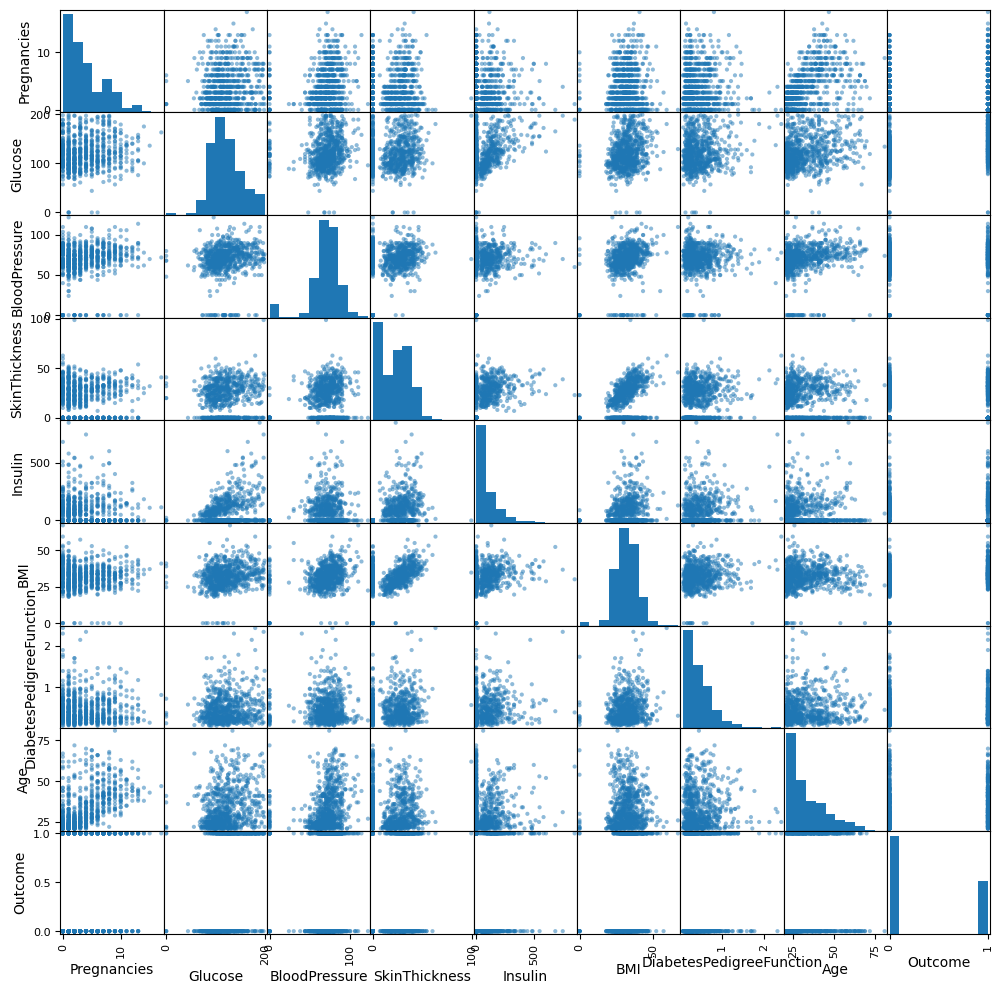

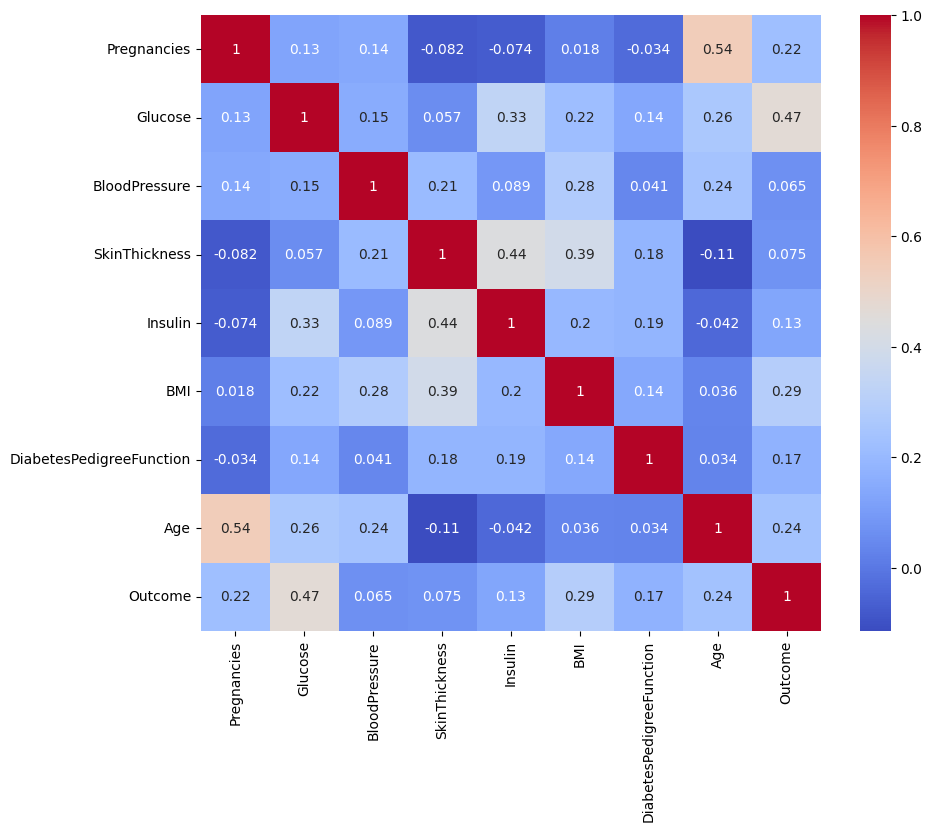

In [ ]:
# Q.2
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns

df = pd.read_excel("SET-A Q-2 DATASET.xlsx")

# Scatter Matrix
scatter_matrix(df, figsize=(12,12))

plt.show()

# Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

In [ ]:
# Q.3
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_excel("SET-A Q-3 DATASET.xlsx")

# Features
X = df[['TV_Ad_Budget',
        'Radio_Ad_Budget',
        'Social_Media_Ad_Budget']]

# Target
y = df['Print_Ad_Budget']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model
model = LinearRegression()

model.fit(X_train, y_train)

# Coefficients
print("Coefficients:", model.coef_)

# Intercept
print("Intercept:", model.intercept_)

Coefficients: [-0.00083879  0.04823115 -0.00356766]
Intercept: 4395.664795355036


In [ ]:
# Q.4
import pandas as pd

df = pd.read_excel("SET-A Q-4 DATASET.xlsx")

data = df['Manhours_of_Labour']

# Mean
print("Mean:", data.mean())

# Standard Deviation
print("Standard Deviation:", data.std())

# Variance
print("Variance:", data.var())

# Sample Size
print("Sample Size:", data.count())

# Degree of Freedom
print("Degree of Freedom:", data.count()-1)

Mean: 110.0
Standard Deviation: 38.95866755649862
Variance: 1517.7777777777778
Sample Size: 10
Degree of Freedom: 9


In [ ]:
# Q.5
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_excel("SET-A Q-5 DATASET.xlsx")

# Convert categorical columns
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# REMOVE DATE COLUMN
df = df.drop(columns=['Transaction_Date'])

# Features and Target
X = df.drop('Fraudulent', axis=1)

y = df['Fraudulent']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression Model
model = LogisticRegression(max_iter=1000)

# Train Model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.66
